In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
def plot_svc_boundary(model, ax=None, plot_margin=True, plot_support=True):
    """Plot the decision boundary for a 2D SVC"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 50)
    y = np.linspace(ylim[0], ylim[1], 50)
    Y, X = np.meshgrid(y, x)

    # shape data
    xy = np.vstack([X.ravel(), Y.ravel()]).T

    # get the decision boundary
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    if plot_margin:
        levels=[-1, 0, 1]
        linestyles=['--', '-', '--']
    else:
        levels=[0]
        linestyles=['-']
    ax.contour(X, Y, P, colors='k', levels=levels, alpha=0.5, linestyles=linestyles)


    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    return ax  # in case plot was created here


C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.01, 0.1, 1, 10, 100]

In [4]:
df = pd.read_csv("crazy_dataset.csv")
df.head()

,x1,x2,y
0,17.328264,15.386803,1
1,19.162757,-276.665450,1
2,18.243497,-32.337063,1
3,16.263083,-8.270111,1
4,16.683013,272.555702,0


/tmp/ipykernel_13625/1486169738.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  obs = [(20 -X_mean[0])/X_std[0], (0 - X_mean[1])/X_std[1]]


[1]


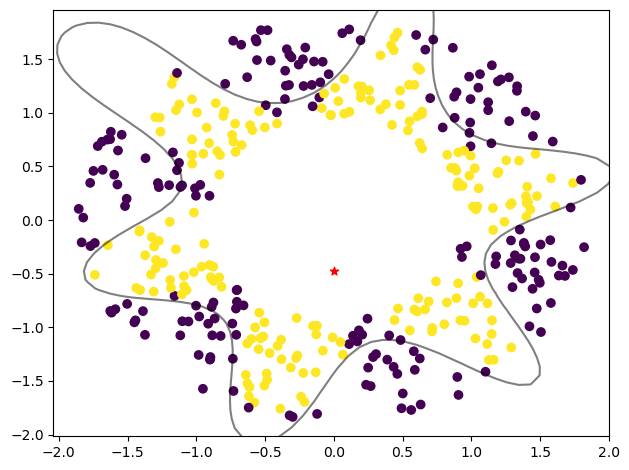

In [8]:
def g1():
    df = pd.read_csv("crazy_dataset.csv")
    #print(df.head())
    
    X = df.iloc[:, :-1]
    y= df.y
    
    X_mean = X.mean()
    X_std = X.std()
    
    X = (X - X.mean()) / X.std()
    
    ng, ax = plt.subplots(tight_layout=True)
    ax.scatter(X.x1, X.x2, c=y)
    
    clf= SVC(kernel="rbf", C=10, gamma=0.8)
    clf.fit(X.values,y)
    
    obs = [(20 -X_mean[0])/X_std[0], (0 - X_mean[1])/X_std[1]]
    
    y_hat= clf.predict([obs])
    plot_svc_boundary(clf, ax, plot_margin=False, plot_support=False)
    print(y_hat)
    plt.scatter(obs[0], obs[1], c = "red", marker = "*")
g1()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from joblib import dump, load
import skimage.transform as tx
import skimage.io as io

In [11]:
def g2_1():
    df = pd.read_csv("mnist.zip")
    #print(df.head())
    df = df[:1000]
    X = df.iloc[:, :-1]
    y = df.y
    X = X/ 255
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
    clf = SVC()
    print("A treinar modelo....")
    clf.fit(X_train, y_train)
    print("A classificar....")
    y_pred = clf.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test,y_pred))
    dump(clf, "clf.pkl")
g2_1()

A treinar modelo....
A classificar....
[[23  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  1  0  0  0  0  0  0]
 [ 1  0 17  0  0  0  0  0  0  0]
 [ 0  0  1 13  0  0  0  0  0  0]
 [ 0  0  1  0 21  0  0  0  0  1]
 [ 1  0  0  1  0 18  0  0  1  0]
 [ 0  0  1  0  0  0 16  0  0  0]
 [ 0  0  1  0  0  0  0 31  0  0]
 [ 0  0  0  0  1  2  0  0 16  0]
 [ 1  0  0  0  0  0  0  0  0 10]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       1.00      0.95      0.98        22
           2       0.81      0.94      0.87        18
           3       0.87      0.93      0.90        14
           4       0.95      0.91      0.93        23
           5       0.90      0.86      0.88        21
           6       1.00      0.94      0.97        17
           7       1.00      0.97      0.98        32
           8       0.94      0.84      0.89        19
           9       0.91      0.91      0.91        11

    accuracy                      